<a href="https://colab.research.google.com/github/dellahi49/AML_ADL_Project/blob/main/AML_ADL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Création des dossiers du projet dans Google Drive
# ============================================================

import os

PROJECT_DIR = "/content/drive/MyDrive/AML_ADL_Project"

folders = [
    PROJECT_DIR,
    f"{PROJECT_DIR}/models",
    f"{PROJECT_DIR}/results",
    f"{PROJECT_DIR}/figures",
    f"{PROJECT_DIR}/exports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Projet créé avec succès")

Projet créé avec succès


In [ ]:
# ============================================================
# Installation des bibliothèques nécessaires au projet
# ============================================================

!pip install -q xgboost
!pip install -q lightgbm
!pip install -q umap-learn
!pip install -q shap
!pip install -q timm

In [ ]:
# ============================================================
# Importation des bibliothèques Python
# ============================================================

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import umap
import shap

In [ ]:
# ============================================================
# Reproductibilité des expériences
# Les mêmes résultats seront obtenus à chaque exécution
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", DEVICE)

Device : cuda


In [ ]:
# ============================================================
# Chargement du dataset CIFAR-10
#
# Resize vers 224x224 :
# nécessaire pour ResNet18 pré-entraîné sur ImageNet
#
# Normalisation :
# mêmes statistiques qu'ImageNet
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
DATA_DIR = "/content/drive/MyDrive/AML_ADL_Project/dataset"

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

In [ ]:
# ============================================================
# Création des DataLoaders
#
# batch_size = nombre d'images traitées simultanément
# shuffle=True pour mélanger les données d'entraînement
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

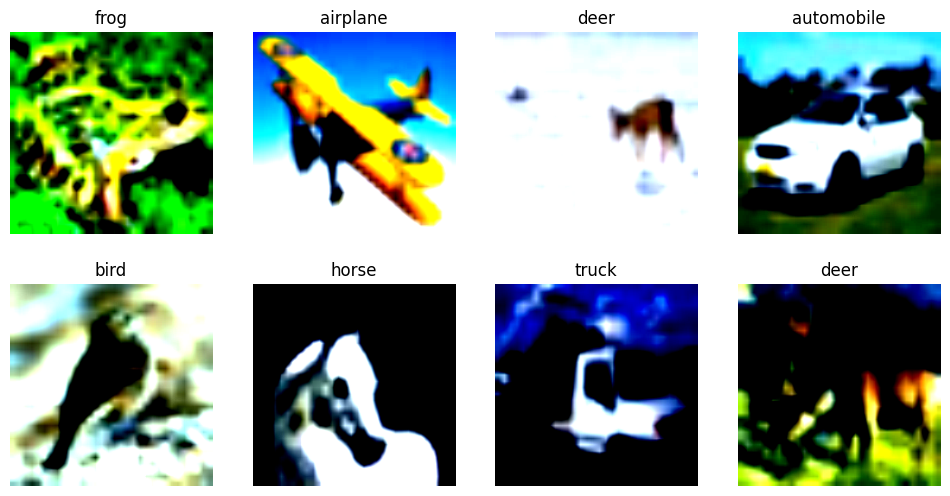

In [ ]:
# ============================================================
# Affichage d'un échantillon d'images du dataset
#
# Les images sont dénormalisées uniquement pour l'affichage
# ============================================================

classes = train_dataset.classes

images, labels = next(iter(train_loader))

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0)

    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
# ============================================================
# Chargement de ResNet18 pré-entraîné sur ImageNet
#
# La couche finale de classification est supprimée
# afin d'utiliser le réseau comme extracteur de features
#
# Sortie attendue :
# vecteur de caractéristiques de taille 512
# ============================================================

resnet = models.resnet18(weights="IMAGENET1K_V1")

resnet.fc = nn.Identity()

resnet = resnet.to(DEVICE)

resnet.eval()

print(resnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# ============================================================
# Fonction d'extraction des Deep Features
#
# Entrée :
#   DataLoader
#
# Sortie :
#   X : matrice des caractéristiques (N x 512)
#   y : labels associés
# ============================================================

def extract_features(model, dataloader, device):

    features = []
    labels = []

    model.eval()

    with torch.no_grad():

        for images, targets in dataloader:

            images = images.to(device)

            outputs = model(images)

            features.append(outputs.cpu().numpy())
            labels.append(targets.numpy())

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)

    return X, y

In [ ]:
# ============================================================
# Extraction des caractéristiques de l'ensemble d'entraînement
# ============================================================

start = time.time()

X_train_features, y_train = extract_features(
    resnet,
    train_loader,
    DEVICE
)

end = time.time()

print("Temps d'extraction :", round(end-start,2), "secondes")

print("Shape des features :", X_train_features.shape)
print("Shape des labels   :", y_train.shape)

Temps d'extraction : 4593.78 secondes
Shape des features : (50000, 512)
Shape des labels   : (50000,)


In [ ]:
# ============================================================
# Extraction des caractéristiques de l'ensemble de test
# ============================================================

start = time.time()

X_test_features, y_test = extract_features(
    resnet,
    test_loader,
    DEVICE
)

end = time.time()

print("Temps d'extraction :", round(end-start,2), "secondes")

print("Shape des features :", X_test_features.shape)
print("Shape des labels   :", y_test.shape)

Temps d'extraction : 915.87 secondes
Shape des features : (10000, 512)
Shape des labels   : (10000,)


In [ ]:
# ============================================================
# Vérification des caractéristiques extraites
# ============================================================

print("Nombre d'images train :", X_train_features.shape[0])
print("Nombre de features    :", X_train_features.shape[1])

print("\nPremières valeurs :")

print(X_train_features[0][:20])

Nombre d'images train : 50000
Nombre de features    : 512

Premières valeurs :
[0.0140779  0.99545485 0.51046085 0.24443476 0.06702072 0.7463345
 1.2813089  0.36032456 0.09110696 0.40185612 1.6593374  0.46975622
 1.3281904  0.07250316 2.1631718  0.29594314 0.9804634  2.2169821
 1.2343682  1.6268065 ]


In [ ]:
# ============================================================
# Sauvegarde des features
# ============================================================

np.save(
    f"{PROJECT_DIR}/exports/X_train_features.npy",
    X_train_features
)

np.save(
    f"{PROJECT_DIR}/exports/y_train.npy",
    y_train
)

np.save(
    f"{PROJECT_DIR}/exports/X_test_features.npy",
    X_test_features
)

np.save(
    f"{PROJECT_DIR}/exports/y_test.npy",
    y_test
)

print("Features sauvegardées avec succès.")

Features sauvegardées avec succès.


In [ ]:
# ============================================================
# Vérification des fichiers sauvegardés
# ============================================================

import os

export_dir = f"{PROJECT_DIR}/exports"

for file in os.listdir(export_dir):
    print(file)

X_train_features.npy
y_train.npy
X_test_features.npy
y_test.npy


In [ ]:
# ============================================================
# Chargement des features déjà extraites
# ============================================================

X_train_features = np.load(
    f"{PROJECT_DIR}/exports/X_train_features.npy"
)

y_train = np.load(
    f"{PROJECT_DIR}/exports/y_train.npy"
)

X_test_features = np.load(
    f"{PROJECT_DIR}/exports/X_test_features.npy"
)

y_test = np.load(
    f"{PROJECT_DIR}/exports/y_test.npy"
)

print("Train :", X_train_features.shape)
print("Test  :", X_test_features.shape)

Train : (50000, 512)
Test  : (10000, 512)


In [ ]:
# ============================================================
# Random Forest sur les Deep Features extraites par ResNet18
# ============================================================

start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train_features, y_train)

end = time.time()

print("Temps d'entraînement :", round(end-start,2), "secondes")

Temps d'entraînement : 427.64 secondes


In [ ]:
# ============================================================
# Prédictions sur l'ensemble de test
# ============================================================

y_pred_rf = rf_model.predict(X_test_features)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy RF :", round(accuracy_rf*100,2), "%")

Accuracy RF : 82.62 %


In [ ]:
# ============================================================
# Rapport détaillé de classification
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

    airplane       0.85      0.86      0.85      1000
  automobile       0.90      0.91      0.90      1000
        bird       0.83      0.71      0.76      1000
         cat       0.67      0.75      0.71      1000
        deer       0.77      0.77      0.77      1000
         dog       0.81      0.75      0.78      1000
        frog       0.82      0.89      0.85      1000
       horse       0.85      0.83      0.84      1000
        ship       0.88      0.91      0.89      1000
       truck       0.89      0.89      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



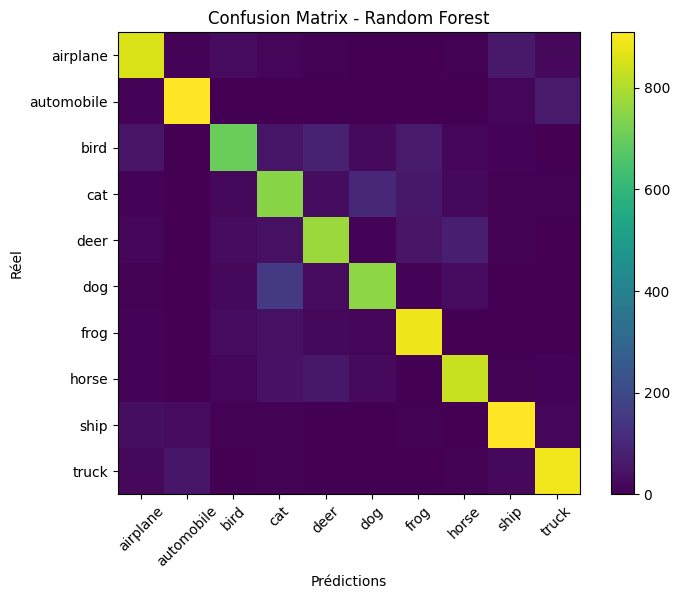

In [ ]:
# ============================================================
# Matrice de confusion
# ============================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    np.arange(len(train_dataset.classes)),
    train_dataset.classes,
    rotation=45
)

plt.yticks(
    np.arange(len(train_dataset.classes)),
    train_dataset.classes
)

plt.xlabel("Prédictions")
plt.ylabel("Réel")

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [ ]:
# ============================================================
# Réduction de dimension par ACP (PCA)
# ============================================================

pca = PCA(
    n_components=100,
    random_state=SEED
)

X_train_pca = pca.fit_transform(X_train_features)

X_test_pca = pca.transform(X_test_features)

print("Avant PCA :", X_train_features.shape)
print("Après PCA :", X_train_pca.shape)

Avant PCA : (50000, 512)
Après PCA : (50000, 100)


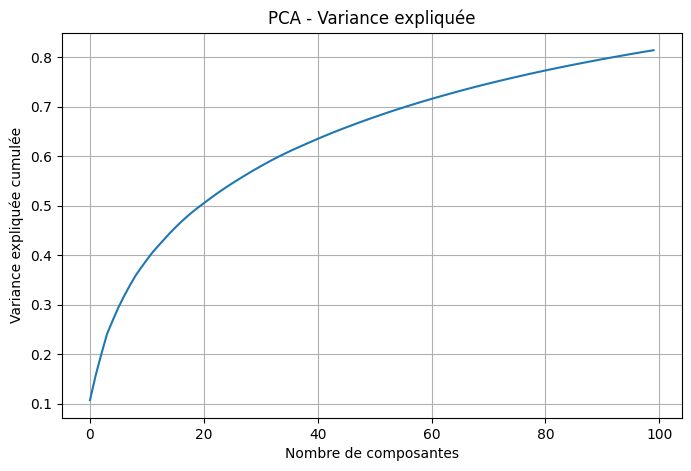

In [ ]:
# ============================================================
# Variance expliquée par les composantes principales
# ============================================================

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(explained_variance)

plt.xlabel("Nombre de composantes")

plt.ylabel("Variance expliquée cumulée")

plt.title("PCA - Variance expliquée")

plt.grid()

plt.show()

In [ ]:
# ============================================================
# Random Forest après réduction PCA
# ============================================================

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)

acc_rf_pca = accuracy_score(
    y_test,
    y_pred_rf_pca
)

print(
    "Accuracy RF + PCA :",
    round(acc_rf_pca*100,2),
    "%"
)

Accuracy RF + PCA : 82.13 %


In [ ]:
# ============================================================
# Réduction de dimension avec UMAP
# ============================================================

reducer = umap.UMAP(
    n_components=50,
    random_state=SEED
)

X_train_umap = reducer.fit_transform(
    X_train_features
)

X_test_umap = reducer.transform(
    X_test_features
)

print(X_train_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(50000, 50)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


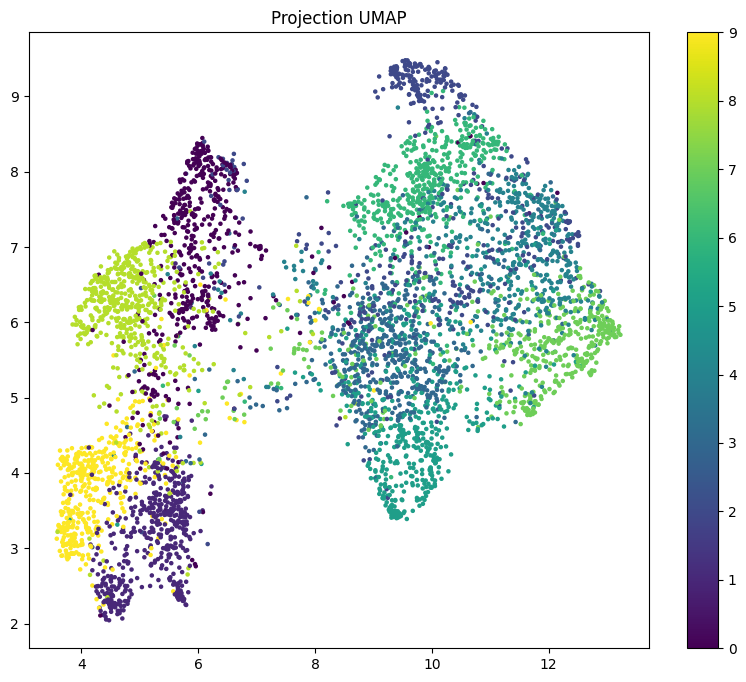

In [ ]:
# ============================================================
# Projection UMAP en 2 dimensions
# ============================================================

reducer_vis = umap.UMAP(
    n_components=2,
    random_state=SEED
)

embedding = reducer_vis.fit_transform(
    X_train_features[:5000]
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=y_train[:5000],
    s=5
)

plt.colorbar(scatter)

plt.title("Projection UMAP")

plt.show()

In [ ]:
# ============================================================
# Random Forest après UMAP
# ============================================================

rf_umap = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf_umap.fit(X_train_umap, y_train)

y_pred_rf_umap = rf_umap.predict(
    X_test_umap
)

acc_rf_umap = accuracy_score(
    y_test,
    y_pred_rf_umap
)

print(
    "Accuracy RF + UMAP :",
    round(acc_rf_umap*100,2),
    "%"
)

Accuracy RF + UMAP : 81.55 %


In [ ]:
# ============================================================
# XGBoost sur les features PCA
# ============================================================

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=SEED,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_pca, y_train)

end = time.time()

print("Temps d'entraînement :", round(end-start,2), "secondes")

Temps d'entraînement : 209.9 secondes


In [ ]:
# ============================================================
# Évaluation du modèle XGBoost
# ============================================================

y_pred_xgb = xgb_model.predict(X_test_pca)

acc_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print(
    "Accuracy XGBoost :",
    round(acc_xgb*100,2),
    "%"
)

Accuracy XGBoost : 85.38 %


In [ ]:
# ============================================================
# LightGBM sur les features PCA
# ============================================================

lgbm_model = LGBMClassifier(
    n_estimators=200,
    random_state=SEED
)

lgbm_model.fit(
    X_train_pca,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.108730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25500
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 100
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


LGBMClassifier(n_estimators=200, random_state=42)

In [ ]:
# ============================================================
# Évaluation du modèle LightGBM
# ============================================================

y_pred_lgbm = lgbm_model.predict(
    X_test_pca
)

acc_lgbm = accuracy_score(
    y_test,
    y_pred_lgbm
)

print(
    "Accuracy LightGBM :",
    round(acc_lgbm*100,2),
    "%"
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy LightGBM : 85.92 %


In [ ]:
# ============================================================
# Construction du modèle Stacking
# ============================================================

estimators = [

    (
        'rf',
        RandomForestClassifier(
            n_estimators=100,
            random_state=SEED
        )
    ),

    (
        'xgb',
        XGBClassifier(
            n_estimators=100,
            eval_metric='mlogloss',
            random_state=SEED
        )
    ),

    (
        'lgbm',
        LGBMClassifier(
            n_estimators=100,
            random_state=SEED
        )
    )
]

In [ ]:
# ============================================================
# Entraînement du Stacking
# ============================================================

stack_model = StackingClassifier(

    estimators=estimators,

    final_estimator=LogisticRegression(
        max_iter=1000
    ),

    n_jobs=-1
)

stack_model.fit(
    X_train_pca,
    y_train
)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              gr...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   n_jobs=-1)

In [ ]:
# ============================================================
# Évaluation du Stacking
# ============================================================

y_pred_stack = stack_model.predict(
    X_test_pca
)

acc_stack = accuracy_score(
    y_test,
    y_pred_stack
)

print(
    "Accuracy Stacking :",
    round(acc_stack*100,2),
    "%"
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy Stacking : 85.51 %


In [ ]:
# ============================================================
# Comparaison des modèles
# ============================================================

results = pd.DataFrame({

    "Modèle":[

        "Random Forest",

        "Random Forest + PCA",

        "Random Forest + UMAP",

        "XGBoost + PCA",

        "LightGBM + PCA",

        "Stacking + PCA"
    ],

    "Accuracy":[

        accuracy_rf,

        acc_rf_pca,

        acc_rf_umap,

        acc_xgb,

        acc_lgbm,

        acc_stack
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Modèle,Accuracy
4,LightGBM + PCA,0.8592
5,Stacking + PCA,0.8551
3,XGBoost + PCA,0.8538
0,Random Forest,0.8262
1,Random Forest + PCA,0.8213
2,Random Forest + UMAP,0.8155


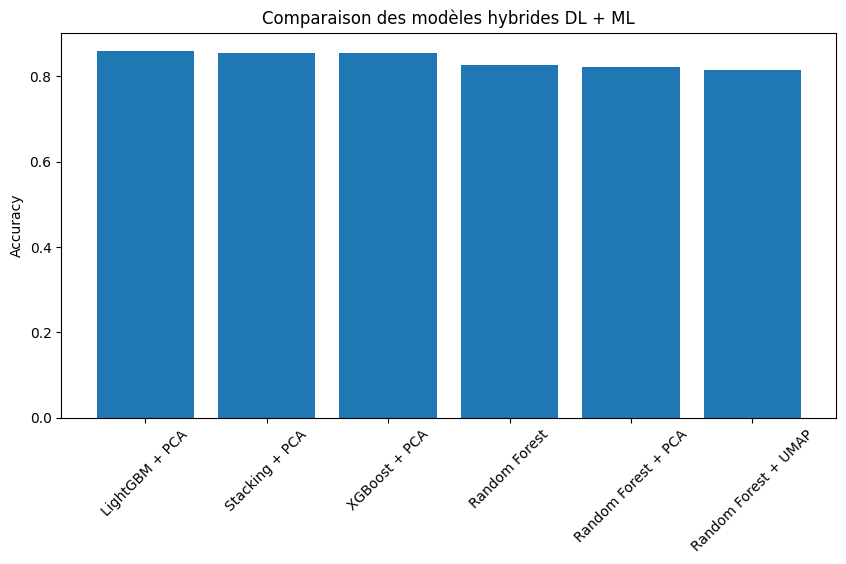

In [ ]:
# ============================================================
# Visualisation des performances
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    results["Modèle"],
    results["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title(
    "Comparaison des modèles hybrides DL + ML"
)

plt.show()

In [ ]:
# ============================================================
# Explainabilité avec SHAP
# ============================================================

explainer = shap.TreeExplainer(
    xgb_model
)

sample = X_test_pca[:500]

shap_values = explainer.shap_values(
    sample
)

/tmp/ipykernel_2588/3195025522.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy gl

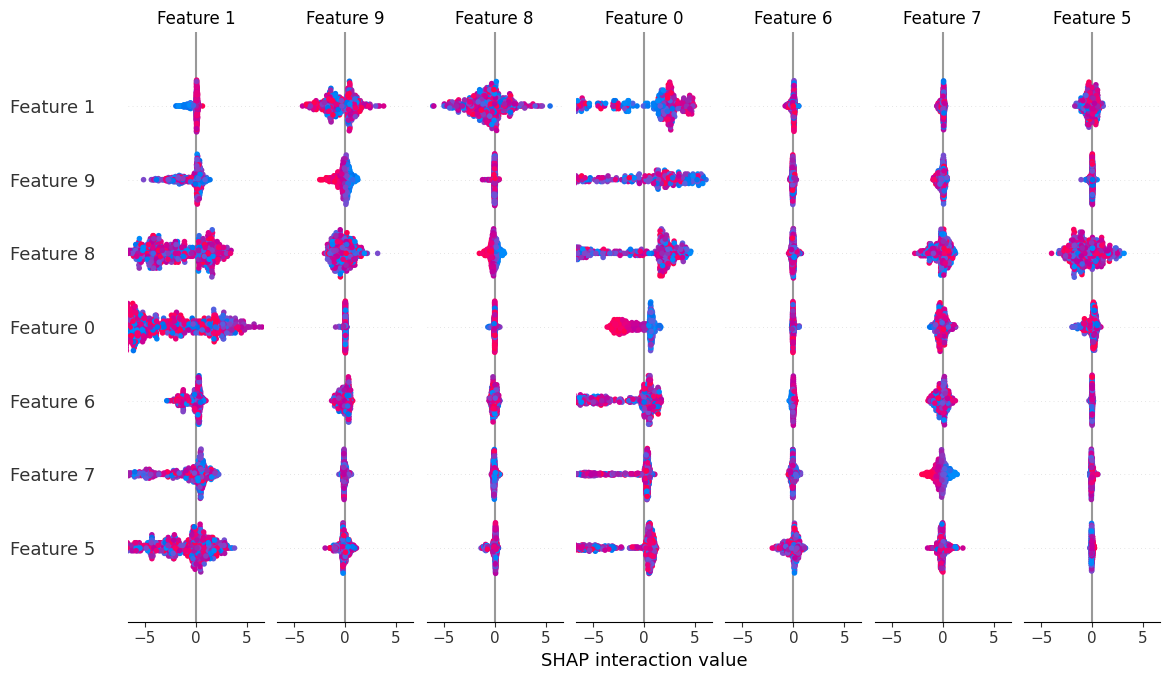

In [ ]:
# ============================================================
# Importance globale des caractéristiques
# ============================================================

shap.summary_plot(
    shap_values,
    sample
)

In [ ]:
# ============================================================
# Sauvegarde du modèle Random Forest
# ============================================================

import joblib

joblib.dump(
    rf_model,
    f"{PROJECT_DIR}/models/random_forest.pkl"
)

print("Random Forest sauvegardé.")

Random Forest sauvegardé.


In [ ]:
# ============================================================
# Sauvegarde du modèle XGBoost
# ============================================================

joblib.dump(
    xgb_model,
    f"{PROJECT_DIR}/models/xgboost.pkl"
)

print("XGBoost sauvegardé.")

XGBoost sauvegardé.


In [ ]:
# ============================================================
# Sauvegarde du modèle LightGBM
# ============================================================

joblib.dump(
    lgbm_model,
    f"{PROJECT_DIR}/models/lightgbm.pkl"
)

print("LightGBM sauvegardé.")

LightGBM sauvegardé.


In [ ]:
# ============================================================
# Sauvegarde du modèle Stacking
# ============================================================

joblib.dump(
    stack_model,
    f"{PROJECT_DIR}/models/stacking.pkl"
)

print("Stacking sauvegardé.")

Stacking sauvegardé.


In [ ]:
# ============================================================
# Sauvegarde des résultats dans un fichier CSV
# ============================================================

results.to_csv(
    f"{PROJECT_DIR}/results/final_results.csv",
    index=False
)

results

,Modèle,Accuracy
4,LightGBM + PCA,0.8592
5,Stacking + PCA,0.8551
3,XGBoost + PCA,0.8538
0,Random Forest,0.8262
1,Random Forest + PCA,0.8213
2,Random Forest + UMAP,0.8155


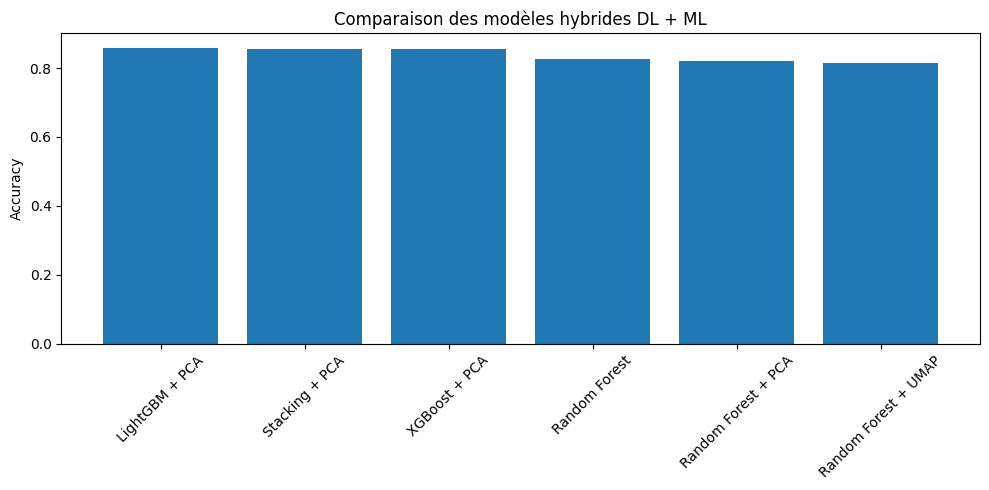

In [ ]:
# ============================================================
# Sauvegarde du graphique de comparaison
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    results["Modèle"],
    results["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title(
    "Comparaison des modèles hybrides DL + ML"
)

plt.tight_layout()

plt.savefig(
    f"{PROJECT_DIR}/figures/models_comparison.png"
)

plt.show()

In [ ]:
# ============================================================
# Vérification des fichiers générés
# ============================================================

for root, dirs, files in os.walk(PROJECT_DIR):

    for file in files:

        print(os.path.join(root, file))

/content/drive/MyDrive/AML_ADL_Project/models/random_forest.pkl
/content/drive/MyDrive/AML_ADL_Project/models/xgboost.pkl
/content/drive/MyDrive/AML_ADL_Project/models/lightgbm.pkl
/content/drive/MyDrive/AML_ADL_Project/models/stacking.pkl
/content/drive/MyDrive/AML_ADL_Project/results/final_results.csv
/content/drive/MyDrive/AML_ADL_Project/figures/models_comparison.png
/content/drive/MyDrive/AML_ADL_Project/exports/X_train_features.npy
/content/drive/MyDrive/AML_ADL_Project/exports/y_train.npy
/content/drive/MyDrive/AML_ADL_Project/exports/X_test_features.npy
/content/drive/MyDrive/AML_ADL_Project/exports/y_test.npy
/content/drive/MyDrive/AML_ADL_Project/dataset/cifar-10-python.tar.gz
/content/drive/MyDrive/AML_ADL_Project/dataset/cifar-10-batches-py/test_batch
/content/drive/MyDrive/AML_ADL_Project/dataset/cifar-10-batches-py/data_batch_3
/content/drive/MyDrive/AML_ADL_Project/dataset/cifar-10-batches-py/data_batch_2
/content/drive/MyDrive/AML_ADL_Project/dataset/cifar-10-batches-py